<a href="https://colab.research.google.com/github/kellygauna/PDI---Laboratorio-Ordinario/blob/main/P3_EQ_2_LabPDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRACTICA #3 :** *Clustering de una imagen*
##### **EQUIPO #2:**
---

*   Kelly Estefanía de la Rosa Gauna - 2048165
*   Fatima Zoe Elisa Juárez Barrientos - 2004844
*   Melissa Rojas Reséndiz - 2132073

## **PARTE I. CLUSTERING DE IMAGEN**


### **EJERCICIO I. REPRESENTACION DE LA IMAGEN EN EL ESPACIO RGB**

Primeramente, para la representación de una imagen en el espacio RGB debemos seleccionar una imagen RGB. En este caso, escogimos una imagen de un carro de color naranja con un fondo de arboles y montañas. 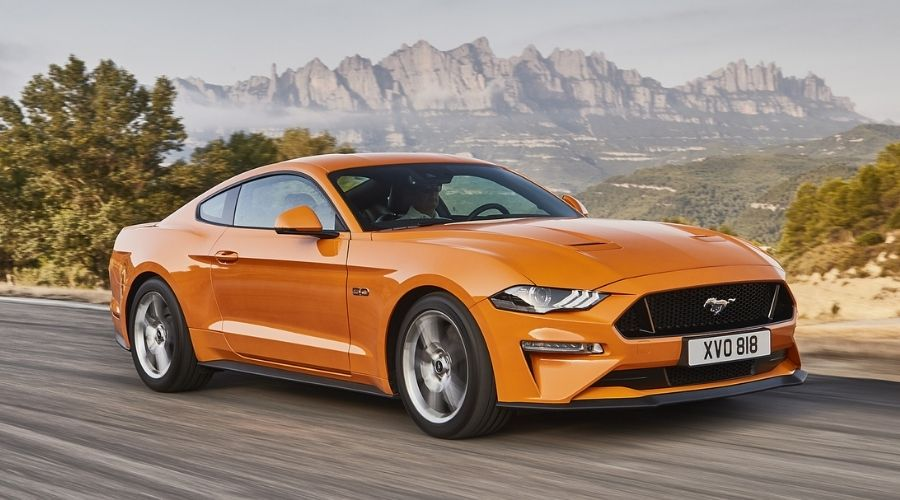

Para la elaboración del código, utilizaremos ciertas librerías que nos facilitaran la lectura, visualización y análisis de las imágenes. Emplearemos OpenCV, Numpy y Matplotlib, y además, mpl_toolkits que nos permite mostrar gráficos en 3D.

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

Después, cargamos la imagen utilizando OpenCV en Python mediante cv.imread(“imagencarro.jpeg”). Para el código la imagen se almacena como una matriz tridimensional donde cada píxel tiene tres valores correspondientes a los canales de color, quedando como: [ alto, ancho, 3 ].


In [30]:
imagencarro = cv2.imread("imagencarro.jpeg")

Ahora, convertiremos la imagen de BGR a RGB porque OpenCV almacena los colores en un orden diferente al estándar que usa Matplotlib para visualizar.

In [31]:
imagencarroRGB = cv2.cvtColor(imagencarro, cv2.COLOR_BGR2RGB)

Ahora, visualizando ambas imágenes obtenidas:

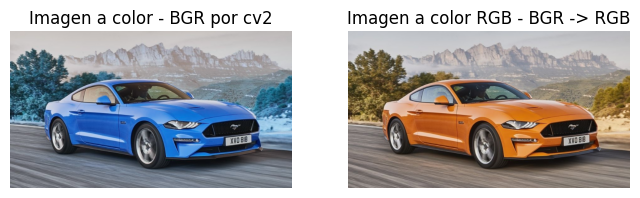

In [32]:
fig1 = plt.figure(figsize=(8, 6))
plt.subplot(1,2,1)
plt.imshow(imagencarro)
plt.title("Imagen a color - BGR por cv2")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagencarroRGB)
plt.title("Imagen a color RGB - BGR -> RGB")
plt.axis("off")

plt.show()

Para la extracción de los valores RGB de todos los píxeles utilizaremos el .reshape((-1, 3)). Este comando reorganiza la imagen en una matriz donde cada fila representa un píxel con sus tres componentes RGB, quedando como: [ R, G, B ].

El -1 en reshape le indica a NumPy el número total de filas de la matriz que se debe obtener de manera automática pero manteniendo las 3 columnas correspondientes a los canales RGB, en este caso 45000 filas, ya que nuestra imagen es de 900 x 500.


In [33]:
pixel_vals = imagencarroRGB.reshape((-1, 3))
pixel_vals = np.float32(pixel_vals)
print("Dimensión de la matriz de píxeles:", pixel_vals.shape) # 900 x 500

Dimensión de la matriz de píxeles: (450000, 3)


Utilizamos esta extracción de valores RGB de cada píxel, ahora establecidos en una matriz, para poder utilizarlos en su visualización en un espacio 3D.

En este caso, vamos a representar **cada píxel como un punto en el espacio RGB**, donde cada eje corresponde a una intensidad de color, el Eje x es Rojo, el Eje y es Verde y el Eje z es Azul, de esta manera, podemos visualizar la distribución en un espacio tridimensional de los colores de la imagen.


Por ende, obtenemos la representación 3D de los píxeles en un espacio tridimensional RGB:

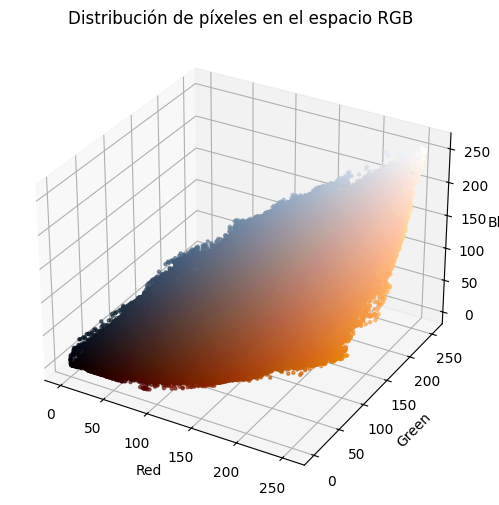

In [34]:
fig2 = plt.figure(figsize=(8, 6))
ax = fig2.add_subplot(111, projection='3d')

r, g, b = pixel_vals[:, 0], pixel_vals[:, 1], pixel_vals[:, 2]
ax.scatter(r, g, b, c=pixel_vals / 255.0, marker='o', s=5, alpha=0.6)
ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue')
ax.set_title('Distribución de píxeles en el espacio RGB')
plt.show()

Con esta gráfica 3D, observamos mayor concentración en las zonas Red y Green, significando que esos colores y sus combinaciones predominan en la imagen.


### **EJERCICIO II. SEGMENTACIÓN CON K-MEANS**

Primero se importan las librerías necesarias para el procesamiento y análisis de la imagen. OpenCV (cv2) se utiliza para cargar y manipular imágenes, NumPy (numpy) para manejar matrices y datos numéricos, Matplotlib (pyplot) para visualizar los resultados y KMeans de sklearn para aplicar el algoritmo de agrupamiento que permitirá segmentar la imagen según la similitud de color de los píxeles


In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

La imagen se carga desde el sistema mediante cv2.imread(). Debido a que OpenCV trabaja con el formato de color BGR, se realiza una conversión al formato RGB utilizando cv2.cvtColor(). También redimensionar la imagen a 100 × 100 píxeles utilizando cv2.resize() para reducir la carga computacional. Para poder aplicar el algoritmo K-means, se debe transformar la imagen en una matriz de la cual cada fila representa un píxel y cada columna un canal RGB, esto se realiza con reshape((-1,3)) para luego convertirlos a datos numéricos flotantes.

In [36]:
#cargar imagen
img = cv2.imread("imagencarro.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#redimension
img_small = cv2.resize(img_rgb, (100, 100))
#convertir a una matriz de pixeles (n_pixeles x 3)
pixel_vals = img_small.reshape((-1, 3))
pixel_vals = np.float32(pixel_vals)

El algoritmo K-means agrupa los píxeles con colores similares en clusters; lo que hacemos es establecer , qué es el número de clusters, luego se crea el modelo KMeans y se entrena con fit(). El algoritmo devuelve las etiquetas de cada píxel y los centroides, que representan el color promedio de cada cluster. Este mismo procedimiento se repite para k = 2, k = 4 y k = 6

In [37]:
#clustering KMeans
#k=2
k1 = 2
kmeans1 = KMeans(n_clusters=k1, random_state=42)
kmeans1.fit(pixel_vals)
labels = kmeans1.labels_
centers1 = np.uint8(kmeans1.cluster_centers_)

Para generar la imagen segmentada, cada píxel se reemplaza por el color promedio del cluster al que pertenece. Posteriormente, los datos se reorganizan nuevamente con reshape() para recuperar la forma original de la imagen y visualizar las regiones segmentadas. También imprimimos los centroides de cada cluster que corresponden a los valores promedio de los canales RGB.

In [38]:
# Crear imagen segmentada
segmented_img1 = centers1[labels.flatten()]
segmented_img1 = segmented_img1.reshape(img_small.shape)
print("Colores promedio de cada cluster para k=2")
print(f"Cluster 1={centers1[0]}")
print(f"Cluster 2={centers1[1]}")

Colores promedio de cada cluster para k=2
Cluster 1=[111  83  56]
Cluster 2=[182 169 161]


In [39]:
#k=4
k2 = 4
kmeans2 = KMeans(n_clusters=k2, random_state=42)
kmeans2.fit(pixel_vals)
labels = kmeans2.labels_
centers2 = np.uint8(kmeans2.cluster_centers_)

segmented_img2 = centers2[labels.flatten()]
segmented_img2 = segmented_img2.reshape(img_small.shape)
print("Colores promedio de cada cluster para k=4")
print(f"Cluster 1={centers2[0]}")
print(f"Cluster 2={centers2[1]}")
print(f"Cluster 3={centers2[2]}")
print(f"Cluster 4={centers2[3]}")

#k=6
k3 = 6
kmeans3 = KMeans(n_clusters=k3, random_state=42)
kmeans3.fit(pixel_vals)
labels = kmeans3.labels_
centers3 = np.uint8(kmeans3.cluster_centers_)

segmented_img3 = centers3[labels.flatten()]
segmented_img3 = segmented_img3.reshape(img_small.shape)
print("Colores promedio de cada cluster para k=6")
print(f"Cluster 1={centers3[0]}")
print(f"Cluster 2={centers3[1]}")
print(f"Cluster 3={centers3[2]}")
print(f"Cluster 4={centers3[3]}")
print(f"Cluster 5={centers3[4]}")
print(f"Cluster 6={centers3[5]}")


Colores promedio de cada cluster para k=4
Cluster 1=[62 50 36]
Cluster 2=[140 129 120]
Cluster 3=[197 189 185]
Cluster 4=[189 111  45]
Colores promedio de cada cluster para k=6
Cluster 1=[38 31 24]
Cluster 2=[166 153 145]
Cluster 3=[201 195 192]
Cluster 4=[196 112  43]
Cluster 5=[130 119 108]
Cluster 6=[92 74 49]


Finalmente, se muestran en una misma figura la imagen original y las imágenes segmentadas para k = 2, 4 y 6 utilizando Matplotlib. Esto permite comparar visualmente cómo cambia la segmentación de la imagen conforme aumenta el número de clusters.

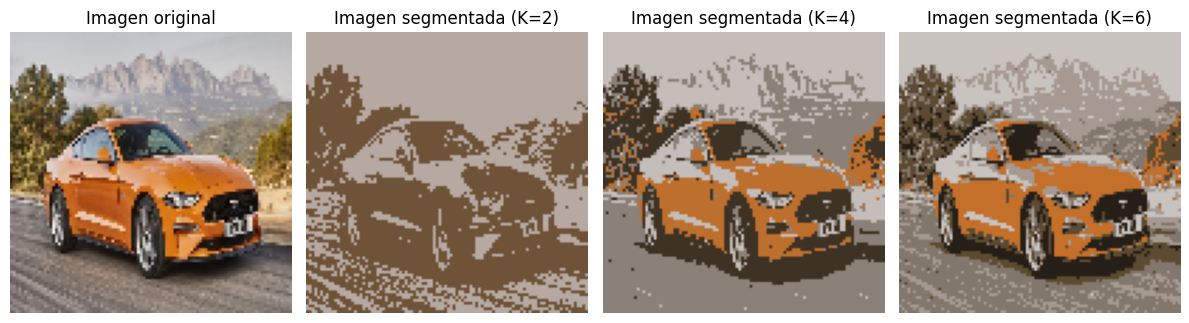

In [40]:
#Graficas
# Imagen original
fig3 = plt.figure(figsize=(12, 6))
plt.subplot(1, 4, 1)
plt.imshow(img_small)
plt.title('Imagen original')
plt.axis('off')
#k=2
plt.subplot(1, 4, 2)
plt.imshow(segmented_img1)
plt.title(f'Imagen segmentada (K={k1})')
plt.axis('off')
#k=4
plt.subplot(1, 4, 3)
plt.imshow(segmented_img2)
plt.title(f'Imagen segmentada (K={k2})')
plt.axis('off')
plt.tight_layout()
#k=6
plt.subplot(1, 4, 4)
plt.imshow(segmented_img3)
plt.title(f'Imagen segmentada (K={k3})')
plt.axis('off')
plt.tight_layout()
plt.show()


### **EJERCICIO III. APLICACIÓN PRÁCTICA**

Primero se exportaron las librerías cv2, numpy, matplotlib.pyplot y KMeans desde sklearn.cluster. La librería **cv2** se utiliza específicamente para leer, convertir y redimensionar la imagen; **numpy** permite manipular los datos de la imagen en forma de arreglos numéricos, lo cual es fundamental para aplicar el algoritmo de clustering, **matplotlib.pyplot** se emplea para visualizar tanto la imagen original como la segmentada y finalmente, **KMeans** es el algoritmo de agrupamiento que se utilizará para segmentar la imagen en diferentes regiones de color.

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

Después se carga la imagen con la función **cv2.imread('paisaje.jpg')**, la cual lee el archivo desde el directorio de trabajo y lo almacena en la variable img. Posteriormente se convierte el espacio de color de BGR a RGB mediante la función **cv2.cvtColor(img, cv2.COLOR_BGR2RGB)**, ya que OpenCV carga las imágenes en formato BGR y Matplotlib las interpreta en formato RGB.

In [43]:
img = cv2.imread('paisaje.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

En el siguiente bloque se redimensiona la imagen utilizando la función **cv2.resize(img_rgb, (200, 200))**. Esto reduce el tamaño a 200x200 píxeles para disminuir la cantidad de datos a procesar y para que sea más rápido.

In [44]:
img_small = cv2.resize(img_rgb, (200, 200))

Luego se reorganizan los datos de la imagen con la instrucción **reshape((-1, 3))**, que transforma la matriz tridimensional (alto, ancho, canales RGB) en una matriz bidimensional donde cada fila representa un píxel y sus tres valores de color. Luego se convierten los datos a tipo float32 usando **np.float32()** para realizar los cálculos de distancia entre puntos y centroides.

In [45]:
pixel_vals = img_small.reshape((-1, 3))
pixel_vals = np.float32(pixel_vals)

A continuación se define el número de clusters con la variable **k = 5**, lo que indica que la imagen se dividirá en cinco grupos de colores. Se crea el modelo mediante **KMeans(n_clusters=k, random_state=42)**, donde n_clusters especifica el número de agrupaciones y random_state hace que los resultados sean reproducibles. Después se entrena el modelo con **kmeans.fit(pixel_vals)**, proceso en el cual el algoritmo calcula los centroides y asigna cada píxel al centroide más cercano según la distancia euclidiana.

In [46]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(pixel_vals)

KMeans(n_clusters=5, random_state=42)

En el siguiente bloque se obtienen las etiquetas de cada píxel mediante **kmeans.labels_**, que indican a qué cluster pertenece cada uno. También se obtienen los centroides con **kmeans.cluster_centers_**, los cuales representan los colores promedio de cada grupo; estos se convierten a enteros sin signo con **np.uint8() **para que puedan representarse correctamente como valores de imagen.

In [47]:
labels = kmeans.labels_
centers = np.uint8(kmeans.cluster_centers_)

Posteriormente se reconstruye la imagen segmentada reemplazando cada píxel por el color de su centroide correspondiente. Esto se hace con **centers[labels.flatten()]**, donde ***flatten()*** convierte las etiquetas en un arreglo unidimensional. Luego se regresa la estructura original de la imagen con **reshape(img_small.shape)** para recuperar las dimensiones espaciales.

In [48]:
segmented_img = centers[labels.flatten()]
segmented_img = segmented_img.reshape(img_small.shape)

Después se crea una figura con **plt.figure(figsize=(12, 5))** y se muestran dos subgráficas usando **plt.subplot()**: la primera visualiza la imagen original y la segunda muestra la imagen segmentada. Se agregan títulos con **plt.title()**, se eliminan los ejes con plt.axis('off'), y finalmente se ajusta el diseño con **plt.tight_layout()** y se presenta todo en pantalla con plt.show().

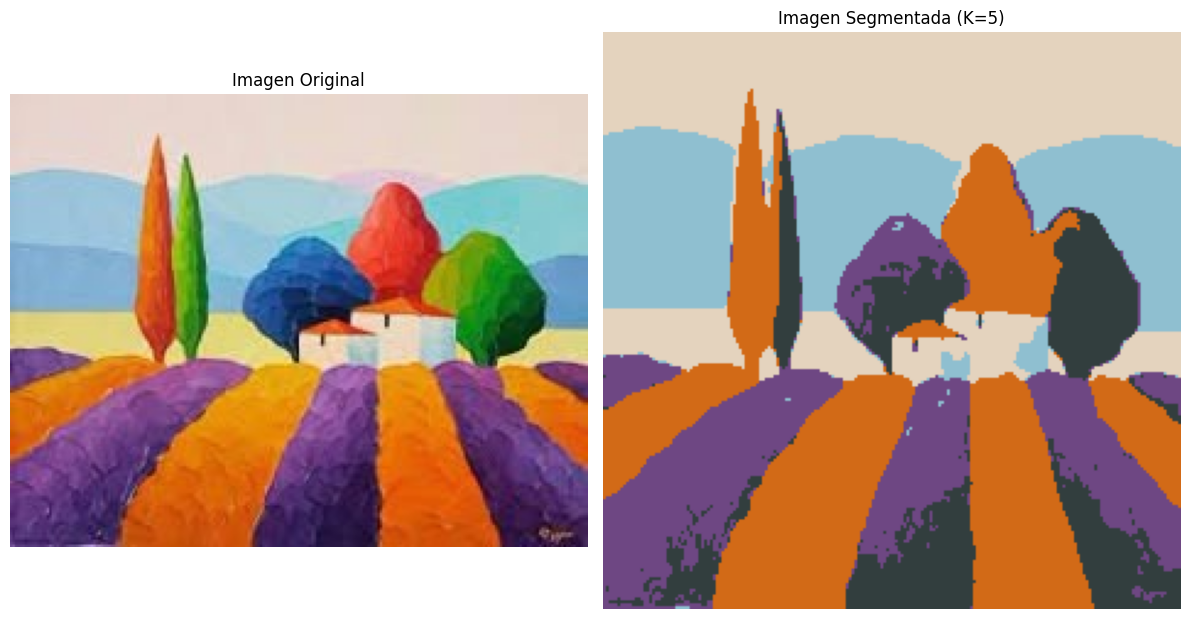

In [52]:
fig = plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_img)
plt.title(f'Imagen Segmentada (K={k})')
plt.axis('off')
plt.tight_layout()
plt.show()

En el último bloque se utiliza un ciclo for que recorre cada uno de los clusters. Para cada región se genera una máscara lógica con la expresión **(labels == i)**, que identifica qué píxeles pertenecen a ese cluster específico. Luego se crea una imagen vacía con **np.zeros_like(pixel_vals)** y se asignan únicamente los píxeles correspondientes al centroide actual. Finalmente se reorganiza nuevamente la forma con reshape(img_small.shape) y se visualiza cada región individual con plt.imshow(), mostrando así cada segmento por separado.

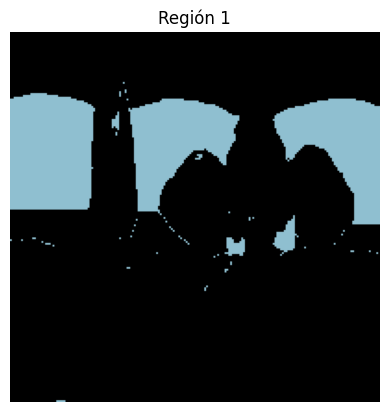

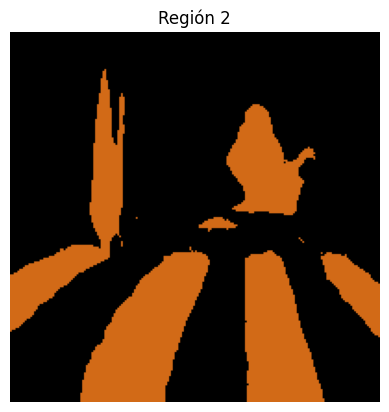

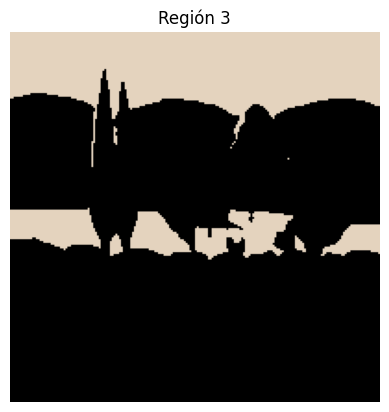

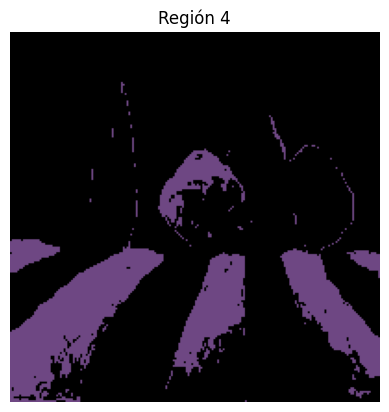

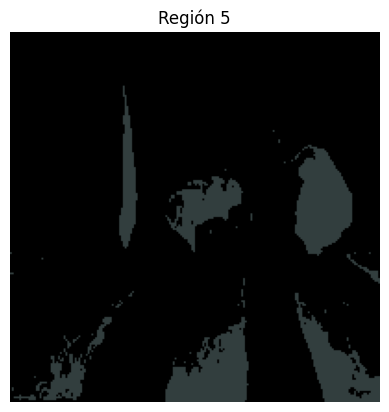

In [53]:
for i in range(k):
    mask = (labels == i)
    region = np.zeros_like(pixel_vals)
    region[mask] = centers[i]

    region = region.reshape(img_small.shape)
    region = region.astype(np.uint8)

    plt.imshow(region)
    plt.title(f'Región {i+1}')
    plt.axis('off')
    plt.show()